# 01.020 Design Thinking Project III

## Overview

The purpose of this project is to apply what you have learnt in this course. This includes working with data and visualizing it, creating a machine learning model, as well as using metrics to measure the accuracy of your model.


## Deliverables

You need to submit this notebook along with the raw dataset.

- `model.ipynb`: This Jupyter notebook.
- `data/Food_Security_data_E_All_Data_(Normalized).csv`: Raw FAOSTAT *Suite of Food Security Indicators* dataset.
- `data/Food_Security_Data_E_AreaCodes.csv`: Lookup table mapping area codes to country and region names.
- `data/Food_Security_Data_E_Flags.csv`: Lookup table defining flags associated with each observation.
- `data/Descriptions_and_Metadata.xlsx`: Detailed descriptions and metadata for all indicators.

## Students Submission

Student's Name:
- Jared Liw Zhi Long (1010278)
- Jerry Lim Jingjie (Lin Jingjie) (1010113)
- Michael Chua Leong Heng (1010563)
- Sathish Kumar S/O Kannan (1009927)
- Sun Yian (1010169)

## Context and Problem Statement

Describe your background, user persona, and problem statement here.

**Background.** Sustainability in food systems is a critical global challenge, as long-term environmental, economic, and social well-being depends on reliable access to sufficient, safe, and nutritious food. Although global hunger has gradually declined since its post-pandemic peak, an estimated 645 million people, or 7.8% of the world's population, remained undernourished in 2025. These figures highlight that undernourishment continues to be a major global concern and emphasize the need to better understand the factors associated with food insecurity.

**User persona.** The primary users of this analysis are government agencies and international organizations involved in sustainable development. They require evidence on the factors associated with food insecurity to prioritize interventions, allocate resources effectively, and monitor progress toward Sustainable Development Goal 2 (Zero Hunger).

**Problem statement.** This project investigates the relationship between food security level and a set of macroeconomic, infrastructure, and population health indicators. Specifically, we seek to answer the following research questions:

- Which factors are strongly associated with the food security level across countries?
- Can these indicators be used to predict food insecurity in future years?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset

- Describe your dataset.
- Put the link to the sources of your raw dataset.
- Put Python codes for loading the data into pandas dataframe(s). The data should be the raw data downloaded from the source. No pre-processing using any software (Excel, Python, etc.) yet. Include this dataset in your submission.
- Explain each column of your dataset (can use comment or Markdown).
- State which column is the dependent variable (target) and explain how it is related to your problem statement.
- State which columns are the independent variables (features) and describe your hypothesis on why these features can predict the target variable.

**Dataset description.** The dataset used in this study is the *Suite of Food Security Indicators* from the Food and Agriculture Organization (FAO) [FAOSTAT database](https://www.fao.org/faostat/en/#data/FS). It consolidates a collection of indicators compiled from FAO and other international organizations, providing standardized statistics that support cross-country and temporal analyses of food security.

The prevalence of undernourishment (PoU), designated as Sustainable Development Goal (SDG) Indicator 2.1.1 for monitoring global hunger, is used as the response variable in this study. A subset of the remaining indicators is selected as predictor variables based on their relevance to the study. Their descriptions are summarized below.

| **Variable** | **Unit**     | **Description**                                                                                                                                                                                                                               |
|--------------|--------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **AC**       | --           | Area code, a numeric identifier representing each country or region.                                                                                                                                                                          |
| **YR**       | --           | Calendar year of observation.                                                                                                                                                                                                                 |
| **PoU**      | %            | *Prevalence of undernourishment*, measured as the percentage of the population whose habitual dietary energy consumption is insufficient to meet the minimum dietary energy requirement for a healthy and active life.                        |
| **GDP**      | $            | *Gross domestic product per capita (purchasing power parity)*, expressed in constant 2021 international dollars, representing the average level of economic development while accounting for differences in purchasing power across countries. |
| **FSV**      | kcal/cap/day | *Per capita food supply variability*, representing the variability of the food supply across countries and over time.                                                                                                                         |
| **DWS**      | %            | *Percentage of population using at least basic drinking water services*, defined as access to an improved water source with a collection time of no more than 30 minutes for a round trip.                                                    |
| **SAN**      | %            | *Percentage of population using at least basic sanitation services*, defined as access to improved sanitation facilities that are not shared with other households.                                                                           |
| **OWC**      | %            | *Percentage of children under 5 years of age who are overweight*, defined as weight-for-height exceeding two standard deviations above the WHO Child Growth Standards median.                                                                 |
| **OBE**      | %            | *Prevalence of obesity in the adult population (18 years and older)*, defined as the percentage of adults with a body mass index (BMI) greater than 30 kg/m².                                                                                 |
| **ANM**      | %            | *Prevalence of anemia among women of reproductive age (15–49 years)*, defined as hemoglobin levels below 12 g/dL for non-pregnant women and below 11 g/dL for pregnant women.                                                                |

Indicators that are conceptually too close to the response variable, such as *average dietary energy supply adequacy* and *percentage of children under 5 years of age who are stunted*, are intentionally excluded. This is to ensure the model learns associations from broader factors rather than relying on near-proxy indicators of undernourishment.

**Hypotheses.** Higher GDP per capita, better access to drinking water, and improved sanitation are expected to be associated with lower PoU because they reflect stronger economic conditions and living standards. In contrast, greater food supply variability and a higher prevalence of anemia are expected to be associated with higher undernourishment due to unstable food availability and poorer nutritional status. The relationships involving childhood overweight and adult obesity are less straightforward, as they may reflect the coexistence of undernutrition and overnutrition within a population.

In [2]:
FILENAME: str = "data/Food_Security_Data_E_All_Data_(Normalized).csv"
FEATURES_RAW: list[str] = [
    "Area Code",
    "Year",
    "Gross domestic product per capita, PPP, (constant 2021 international $)",
    "Per capita food supply variability (kcal/cap/day)",
    "Percentage of population using at least basic drinking water services (percent)",
    "Percentage of population using at least basic sanitation services (percent)",
    "Percentage of children under 5 years of age who are overweight (modelled estimates) (percent)",
    "Prevalence of obesity in the adult population (18 years and older) (percent)",
    "Prevalence of anemia among women of reproductive age (15-49 years) (percent)",
]
AREA_CODE: str = "AC"
YEAR: str = "YR"
FEATURES: list[str] = [
    AREA_CODE,
    YEAR,
    "GDP",
    "FSV",
    "DWS",
    "SAN",
    "OWC",
    "OBE",
    "ANM",
]
TARGET_RAW: str = "Prevalence of undernourishment (percent) (annual value)"
TARGET: str = "PoU"
SPLIT_YEAR: int = 2020

In [3]:
df = pd.read_csv(FILENAME)[["Area Code", "Item", "Year", "Value"]]
df = df[(df["Item"].isin([*FEATURES_RAW, TARGET_RAW])) & (df["Area Code"] >= 1000) & (df["Area Code"] < 5600)]
df.head()

,Area Code,Item,Year,Value
212355,5000,"Gross domestic product per capita, PPP, (const...",2000,12770
212356,5000,"Gross domestic product per capita, PPP, (const...",2001,12905
212357,5000,"Gross domestic product per capita, PPP, (const...",2002,13093
212358,5000,"Gross domestic product per capita, PPP, (const...",2003,13403
212359,5000,"Gross domestic product per capita, PPP, (const...",2004,13915


Here, we retain only regional aggregates (e.g., Western Europe, South-eastern Asia) to reduce missing values and ensure that the model learns from observations at a consistent regional scale.

## Clean & Analyze your data

Use Python code to:
- Clean your data. If the dataset does not require cleaning, write code to validate the data instead (e.g., to ensure future data updates remain accurate and consistent).\
    *Data validation refers to the process of checking that data is accurate, complete, and consistent, and that it meets predefined rules or constraints (e.g., correct formats, correct types, valid ranges, and no missing or duplicate values).*
- Calculate Descriptive Statistics and other statistical analysis.
- Visualization with meaningful analysis description.

In [4]:
df_pivoted = df.pivot_table(
    index=["Area Code", "Year"],
    columns="Item",
    values="Value",
    aggfunc="first",
).reset_index().rename(columns=dict(zip([*FEATURES_RAW, TARGET_RAW], [*FEATURES, TARGET])))

df_pivoted

Item,AC,YR,GDP,FSV,OWC,DWS,SAN,ANM,OBE,PoU
0,5000,2000,12770,10,5.3,82,56,29.3,8.7,12.8
1,5000,2001,12905,7,5.3,82,56,29,9,13
2,5000,2002,13093,8,5.4,82,57,28.8,9.3,13.2
3,5000,2003,13403,11,5.4,83,58,28.7,9.5,12.9
4,5000,2004,13915,13,5.4,83,60,28.5,9.8,12.7
...,...,...,...,...,...,...,...,...,...,...
826,5504,2021,6505,32,8.5,99,94,20.6,57.5,2.8
827,5504,2022,6535,46,8.6,99,94,21.1,58.1,2.9
828,5504,2023,7226,37,8.7,99,94,21.6,58.6,3.5
829,5504,2024,7686,39,8.9,100,94,NaN,59.1,2.7


The data is reshaped into a wide format, with one row per area-year combination and one column for each selected indicator.

In [5]:
pd.unique(df_pivoted.where(df_pivoted.apply(pd.to_numeric, errors="coerce").isna()).stack())

<ArrowStringArray>
[nan, '<2.5']
Length: 2, dtype: str

In [6]:
df_cleaned = df_pivoted.dropna().replace("<2.5", "0").astype(np.float64)

df_cleaned.describe()

Item,AC,YR,GDP,FSV,OWC,DWS,SAN,ANM,OBE,PoU
count,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000
mean,5263.018663,2011.573872,20969.710731,22.158631,7.057854,86.760498,74.001555,26.063919,18.315552,8.700311
std,131.822025,6.902214,17324.346492,21.798633,3.022220,15.323872,24.849108,11.496405,11.215856,7.953984
min,5000.000000,2000.000000,1813.000000,3.000000,1.600000,34.000000,14.000000,7.300000,2.500000,0.000000
25%,5105.000000,2006.000000,7313.500000,11.000000,5.100000,85.000000,62.500000,17.650000,8.700000,0.000000
50%,5301.000000,2012.000000,15452.000000,16.000000,6.800000,91.000000,81.000000,27.400000,18.000000,7.000000
75%,5400.000000,2018.000000,28807.000000,27.000000,8.600000,97.000000,94.000000,31.600000,24.650000,13.300000
max,5504.000000,2023.000000,72455.000000,228.000000,22.400000,100.000000,100.000000,52.900000,58.600000,38.000000


Rows containing missing values are removed. The value `"<2.5"` is treated as a negligible prevalence.

In [7]:
df_cleaned.dtypes

Item
AC     float64
YR     float64
GDP    float64
FSV    float64
OWC    float64
DWS    float64
SAN    float64
ANM    float64
OBE    float64
PoU    float64
dtype: object

To better understand the relationships among the variables, a correlation matrix is computed using the **Pearson correlation coefficient**, defined as

$$
r_{XY}=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}},
$$

where $x_i$ and $y_i$ are paired observations, and $\bar{x}$ and $\bar{y}$ are their respective means. The coefficient ranges from $-1$ to $1$, with values closer to $\pm1$ indicating stronger linear relationships. This helps identify variables that are strongly associated with the target variable.

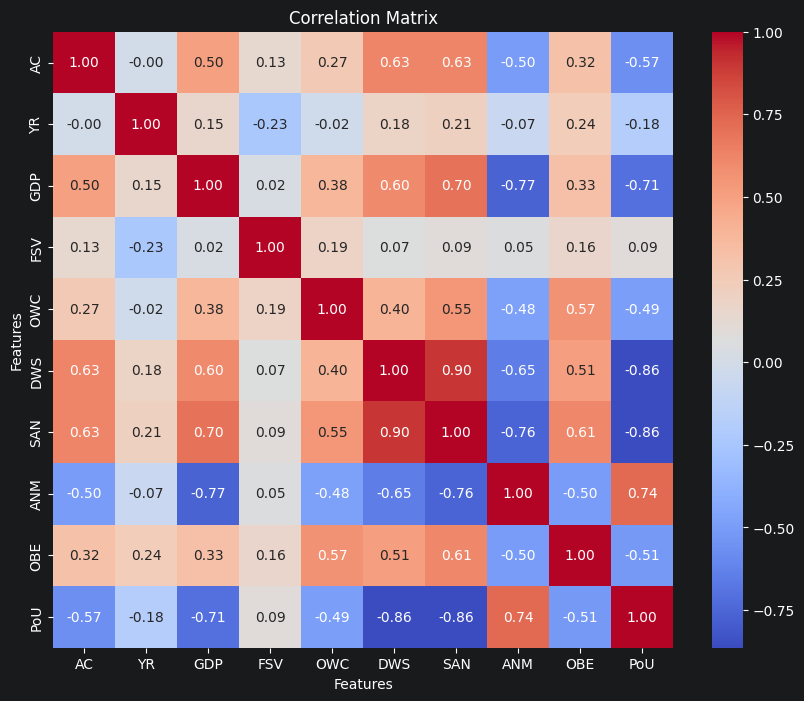

In [8]:
corr_matrix = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features");

In [9]:
sorted_corr_target = corr_matrix[TARGET].sort_values(ascending=False, key=abs)

sorted_corr_target

Item
PoU    1.000000
DWS   -0.863808
SAN   -0.862917
ANM    0.736858
GDP   -0.710405
AC    -0.568438
OBE   -0.514885
OWC   -0.490929
YR    -0.181781
FSV    0.091942
Name: PoU, dtype: float64

The correlation matrix generally supports the hypotheses proposed earlier. GDP, DWS, and SAN are strongly negatively correlated with PoU, suggesting that higher levels of economic development and better access to basic infrastructure are associated with lower undernourishment. Conversely, ANM exhibits a strong positive correlation with PoU, indicating that poorer nutritional status tends to coincide with higher undernourishment.

To illustrate these relationships, scatter plots are generated for some predictors:

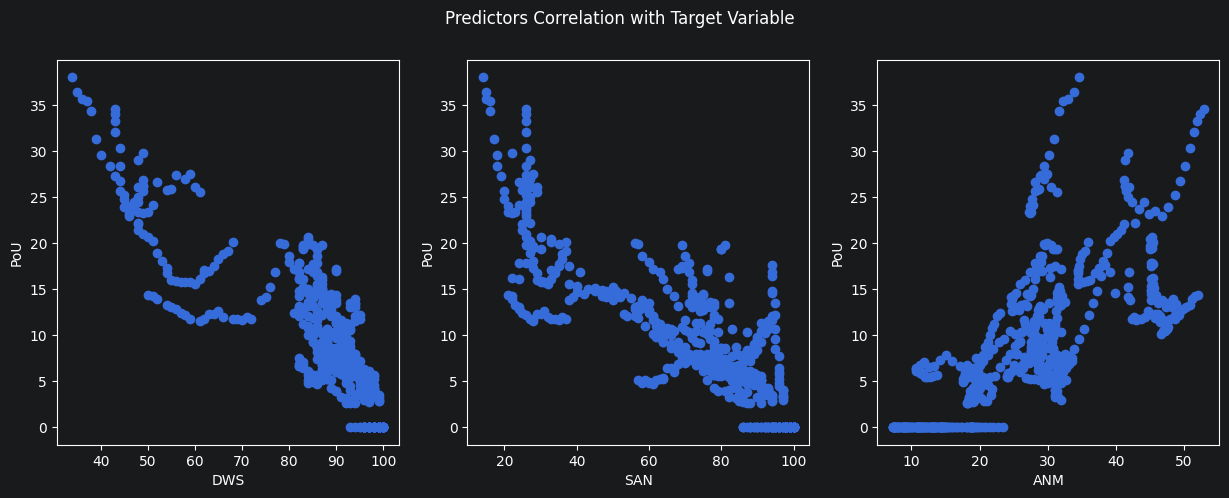

In [10]:
top_cols = sorted_corr_target[1:4].index

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()
for i, col in enumerate(top_cols):
    axes[i].scatter(df_cleaned[col], df_cleaned[TARGET])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
fig.suptitle("Predictors Correlation with Target Variable");

## Features and Target Preparation

Prepare features and target for model training.

The predictor variables are standardized using z-score normalization,

$$
z = \frac{x - \mu}{\sigma},
$$

where $x$ is the original feature value, $\mu$ is the mean, and $\sigma$ is the standard deviation computed from the training set. The same scaling parameters are then applied to the test set to ensure consistent feature scaling during model evaluation.

In [11]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        self.features_ = None

    def fit(self, X):
        self.mean_ = X.mean()
        self.std_ = X.std()
        self.features_ = X.columns
        return self

    def _check(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Encoder has not been fitted.")
        if self.features_ is None or not self.features_.equals(X.columns):
            raise ValueError("Columns does not match fitted data.")

    def transform(self, X):
        self._check(X)
        X = X.copy()
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        self._check(X)
        X = X.copy()
        return X * self.std_ + self.mean_

In [12]:
df_train, df_test = df_cleaned[df_cleaned[YEAR] < SPLIT_YEAR], df_cleaned[df_cleaned[YEAR] >= SPLIT_YEAR]

df_train.shape, df_test.shape

((535, 10), (108, 10))

The dataset is split chronologically, with observations before 2020 used for training and those from 2020 onward reserved for testing. This enables the model to be evaluated on future, unseen data, providing a realistic assessment of its ability to predict PoU trends over time.

In [13]:
ss = StandardScaler()
df_train[FEATURES] = ss.fit_transform(df_train[FEATURES])
df_test[FEATURES] = ss.transform(df_test[FEATURES])

df_train.describe()

Item,AC,YR,GDP,FSV,OWC,DWS,SAN,ANM,OBE,PoU
count,5.350000e+02,5.350000e+02,535.000000,535.000000,5.350000e+02,5.350000e+02,5.350000e+02,5.350000e+02,5.350000e+02,535.000000
mean,-2.815609e-15,1.958475e-14,0.000000,0.000000,1.859364e-16,1.062494e-16,5.312469e-17,-3.187481e-16,-1.925770e-16,8.841869
std,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,7.981735
min,-1.994421e+00,-1.664093e+00,-1.097604,-0.868186,-1.891626e+00,-3.314334e+00,-2.327942e+00,-1.600035e+00,-1.371171e+00,0.000000
25%,-1.198509e+00,-7.946695e-01,-0.799287,-0.527096,-6.807449e-01,-9.549008e-02,-4.995559e-01,-7.192957e-01,-9.161946e-01,2.650000
50%,2.871944e-01,7.475419e-02,-0.323669,-0.271278,-9.260252e-02,2.550771e-01,2.953948e-01,1.101384e-01,1.195695e-02,7.100000
75%,1.037626e+00,9.441779e-01,0.429332,0.197721,5.301365e-01,7.012534e-01,8.518602e-01,4.821011e-01,5.533787e-01,13.400000
max,1.825958e+00,1.639717e+00,2.819447,8.724970,3.955201e+00,8.924718e-01,1.090345e+00,2.299160e+00,3.533473e+00,38.000000


## Building Model

Use Python code to build your model. Give explanation on this process.


**Note: You are NOT allowed to use scikit-learn or any other library to build the machine learning model. You can only use linear regression or logistic regression model you learnt from DDW course.**

**Methodology.** The exploratory analysis indicates that several predictor variables have approximately linear relationships with PoU. Therefore, **linear regression** is adopted to model PoU as a function of the selected predictors.

The linear regression model represents PoU as a linear combination of the predictor variables. For an observation $\mathbf{x}^{(i)}$, the prediction is

$$
\hat{y}^{(i)}
=
w_0+\sum_{j=1}^{p}w_jx_j^{(i)},
$$

where $w_0$ is the intercept, $w_j$ is the coefficient of the $j$-th predictor, and $p$ is the number of predictors. By augmenting the feature matrix with a column of ones, the bias term is incorporated into the weight vector. Let $\tilde{\mathbf X}$ denote the augmented feature matrix. The model can then be written compactly as

$$
\hat{\mathbf y}
=
\tilde{\mathbf X}\mathbf w.
$$

where $\tilde{\mathbf X}$ is the input matrix with a leading column of ones.

The model is trained by minimizing the **mean squared error (MSE)** cost function,

$$
J(\mathbf w)
=
\frac{1}{2n}
\sum_{i=1}^{n}
\left(
\hat y^{(i)}
-
y^{(i)}
\right)^2,
$$

where $n$ is the number of training observations.

This can be expressed in matrix form as

$$
\begin{aligned}
J(\mathbf w)
&=
\frac{1}{2n}
(\mathbf y-\tilde{\mathbf X}\mathbf w)^\top
(\mathbf y-\tilde{\mathbf X}\mathbf w) \\
&=
\frac{1}{2n}
(\mathbf y^\top-\mathbf w^\top\tilde{\mathbf X}^\top)
(\mathbf y-\tilde{\mathbf X}\mathbf w) \\
&=
\frac{1}{2n}
\left(
\mathbf y^\top\mathbf y
-
\mathbf y^\top\tilde{\mathbf X}\mathbf w
-
\mathbf w^\top\tilde{\mathbf X}^\top\mathbf y
+
\mathbf w^\top\tilde{\mathbf X}^\top\tilde{\mathbf X}\mathbf w
\right).
\end{aligned}
$$

Differentiating with respect to $\mathbf w$ gives

$$
\begin{aligned}
\nabla_{\mathbf w}J(\mathbf w)
&=
\frac{1}{2n}
\left(
0
-
(\mathbf y^\top\tilde{\mathbf X})^\top
-
\tilde{\mathbf X}^\top\mathbf y
+
2\tilde{\mathbf X}^\top\tilde{\mathbf X}\mathbf w
\right) \\
&=
\frac{1}{n}
\left(
-
\tilde{\mathbf X}^\top\mathbf y
+
\tilde{\mathbf X}^\top\hat{\mathbf y}
\right) \\
&=
\frac{1}{n}
\tilde{\mathbf X}^\top
(\hat{\mathbf y}-\mathbf y).
\end{aligned}
$$

Instead of solving for the optimal coefficients analytically, the model is trained using batch gradient descent (BGD). The coefficients are initialized to zero and updated iteratively according to

$$
\mathbf w
\leftarrow
\mathbf w
-
\alpha
\nabla_{\mathbf w}J(\mathbf w),
$$

where $\alpha$ is the learning rate. At each iteration, the gradient is computed using the entire training set, and the cost is recorded in `history_` to monitor convergence.

In [14]:
class LinearRegression:
    def __init__(self, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.weights_ = None
        self.history_ = []

    def _predict(self, X):
        return (X @ self.weights_).squeeze()

    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        return self._predict(X)

    def _cost(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / n_samples) * X.T @ (y_hat - y)

    def fit(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))

        n_samples, n_features = X.shape
        self.weights_ = np.zeros((n_features,))
        self.history_ = []

        for _ in range(self.n_iters_):
            self.weights_ -= self.lr_ * self._cost_grad(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

        return self

In [15]:
X_train, y_train = df_train[FEATURES].to_numpy(), df_train[TARGET].to_numpy()
X_test, y_test = df_test[FEATURES].to_numpy(), df_test[TARGET].to_numpy()

In [16]:
lr = LinearRegression(n_iters=10000)
lr.fit(X_train, y_train);

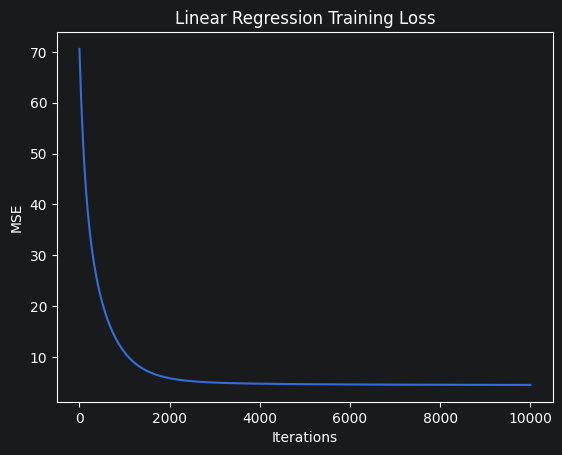

In [17]:
sns.lineplot(lr.history_)
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("Linear Regression Training Loss");

The BGD algorithm successfully minimizes the cost function and converges during training.

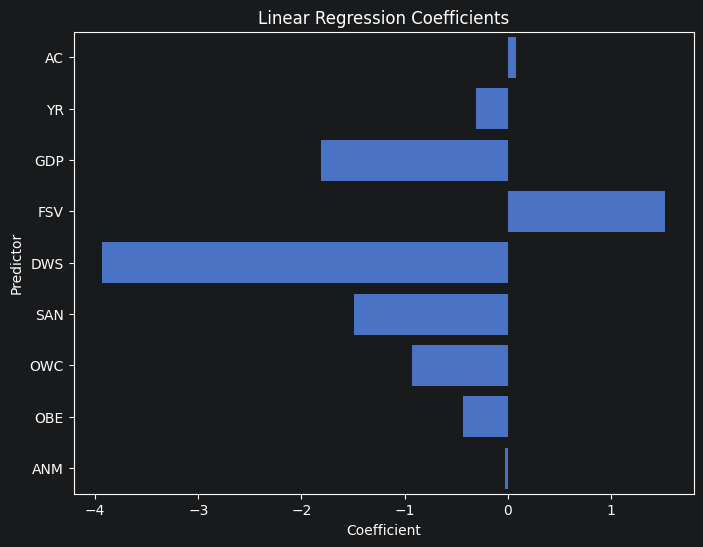

In [18]:
feature_weight_pairs = list(zip(FEATURES, lr.weights_.tolist()[1:]))
coef_df = pd.DataFrame(feature_weight_pairs, columns=["Feature", "Weight"])

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="Weight", y="Feature")
plt.xlabel("Coefficient")
plt.ylabel("Predictor")
plt.title(f"Linear Regression Coefficients");

The fitted regression coefficients are shown below. Each coefficient represents the expected change in PoU associated with a one-unit increase in the corresponding standardized predictor, while holding the remaining predictors constant.

Overall, the estimated coefficients are broadly consistent with the exploratory analysis. DWS has the largest negative coefficient, suggesting that improved access to drinking water is associated with lower PoU. FSV has the largest positive coefficient, indicating that greater food supply variability is associated with higher PoU. GDP, SAN, and OWC also have negative coefficients, implying that higher income levels, improved sanitation, and a higher prevalence of overweight children are associated with lower PoU after controlling for the other predictors.

## Evaluating the Model

- Describe the metrics of your choice.
- Evaluate your model performance.

**Evaluation.** To assess the predictive performance of the model, two evaluation metrics are used: the **coefficient of determination ($R^2$)** and the **Root Mean Squared Error (RMSE)**.

The coefficient of determination is defined as

$$
R^2
=
1
-
\frac{\sum_{i=1}^{n}(y^{(i)}-\hat{y}^{(i)})^2}
{\sum_{i=1}^{n}(y^{(i)}-\bar{y})^2},
$$

where $\bar{y}$ is the mean of the observed PoU values. The $R^2$ score measures the proportion of variance in PoU explained by the model, with values closer to 1 indicating a better fit.

In [19]:
def r2_score(y_true, y_pred):
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true, axis=0)) ** 2))

The RMSE is defined as

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(y^{(i)}-\hat{y}^{(i)}\right)^2
},
$$

where $n$ is the number of test observations. RMSE measures the average prediction error in the same units as the response variable, making it easier to interpret. Lower RMSE values indicate better predictive performance.

In [20]:
def root_mean_squared_error(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2).tolist() ** 0.5)

The model is evaluated on the test set using these metrics. A higher $R^2$ and a lower RMSE indicate better predictive performance and stronger generalization to unseen data.

In [21]:
y_pred = lr.predict(X_test)

In [22]:
r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

(0.7345285478220827, 4.007231074137468)

## Improving the Model

- Improve the models by performing data processing techniques or hyperparameter tuning.
- You can repeat the steps above to show the improvement as compared to the previous performance.

*Note: changing or adding more dataset is not allowed.*

To improve the predictive performance of the model, a **multilayer perceptron (MLP)** is implemented. Unlike linear regression, an MLP is capable of learning complex nonlinear relationships between the predictors and the target through multiple layers of nonlinear transformations. This enables the model to capture patterns that cannot be represented by a linear model.

**Network architecture.** An MLP network consists of a sequence of dense layers separated by nonlinear activation functions.


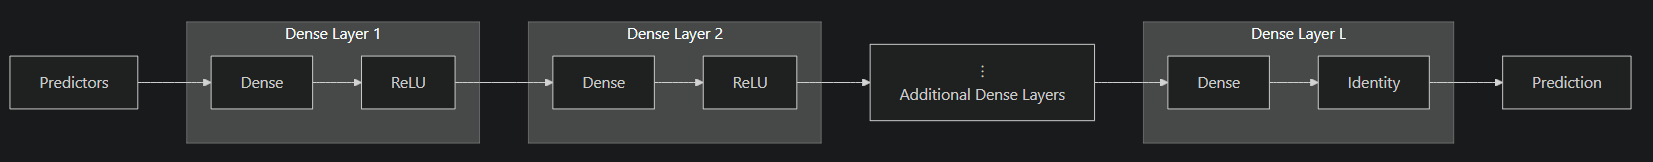



**Forward propagation.** During the forward pass, the input data are propagated sequentially through each layer.

Let $\mathbf a^{(0)}=\mathbf X$ denote the input feature matrix. For the $l$-th dense layer, the pre-activation values are computed as

$$
\mathbf z^{(l)}
=
\tilde{\mathbf A}^{(l-1)}
\mathbf W^{(l)\top},
$$

where $\tilde{\mathbf A}^{(l-1)}$ denotes the output of the previous layer augmented with a column of ones to incorporate the bias term, and $\mathbf W^{(l)}$ is the corresponding weight matrix.

The output of the layer is then obtained by applying an activation function,

$$
\mathbf a^{(l)}
=
f\!\left(
\mathbf z^{(l)}
\right).
$$

For the hidden layers, the Rectified Linear Unit (ReLU) activation function is used,

$$
f(z)=\max(0,z),
$$

whereas the output layer uses the identity function,

$$
f(z)=z.
$$

If the network contains $L$ layers, the final prediction is $\hat{\mathbf y}=\mathbf a^{(L)}$.

**Backward propagation.** The network parameters are optimized using the backpropagation algorithm together with BGD. Backpropagation computes the gradients of the loss with respect to every learnable parameter by repeatedly applying the chain rule from the output layer towards the input layer.

For the output layer, the identity activation function has derivative

$$
\frac{d}{dz}z=1,
$$

and therefore

$$
\delta^{(L)}
=
\frac{\partial J}{\partial\hat{\mathbf y}},
$$

where $\delta^{(l)}=\frac{\partial J}{\partial\mathbf z^{(l)}}$ denotes the error signal of the $l$-th layer.

For a fully connected layer, $\mathbf z^{(l)}=\tilde{\mathbf A}^{(l-1)}\mathbf W^{(l)\top}$, the chain rule gives

$$
\begin{aligned}
\frac{\partial J}{\partial\mathbf W^{(l)}}
&=
\frac{\partial J}{\partial\mathbf z^{(l)}}
\frac{\partial\mathbf z^{(l)}}{\partial\mathbf W^{(l)}} \\
&=
\delta^{(l)\top}
\tilde{\mathbf A}^{(l-1)}.
\end{aligned}
$$

Similarly, the error propagated to the previous layer is

$$
\begin{aligned}
\frac{\partial J}{\partial\mathbf A^{(l-1)}}
&=
\frac{\partial J}{\partial\mathbf z^{(l)}}
\frac{\partial\mathbf z^{(l)}}{\partial\mathbf A^{(l-1)}} \\
&=
\delta^{(l)}
\mathbf W^{(l)},
\end{aligned}
$$

where the first column corresponding to the bias weights is excluded because the bias input is constant.

For each hidden layer, the ReLU activation introduces an additional derivative. Since

$$
f(z)=\max(0,z),
$$

its derivative is

$$
f'(z)
=
\begin{cases}
1,&z>0,\\
0,&z\le0.
\end{cases}
$$

Applying the chain rule gives

$$
\delta^{(l)}
=
\left(
\delta^{(l+1)}
\mathbf W^{(l+1)}
\right)
\odot
f'(\mathbf z^{(l)}),
$$

where $\odot$ denotes element-wise multiplication. Consequently, neurons whose pre-activation values are non-positive do not contribute to the gradients during backpropagation.

**Parameter update.** After the gradients have been computed for every learnable layer, the weights are updated using batch gradient descent,

$$
\mathbf W^{(l)}
\leftarrow
\mathbf W^{(l)}
-
\alpha
\frac{\partial J}{\partial\mathbf W^{(l)}},
$$

where $\alpha$ is the learning rate.

The gradients are computed using the entire training set before each update, and the forward propagation, backpropagation, and weight update steps are repeated until the specified number of training iterations is reached.

In [23]:
class LinearRegressionLayer:
    def __init__(self, n_in, n_out, random_state=None):
        self.learnable_ = True
        self.random_state = random_state
        self.input_ = None
        self.weights_gradient_ = None
        rng = np.random.default_rng(random_state)
        self.weights_ = rng.standard_normal((n_out, n_in + 1)) * np.sqrt(2 / n_in)

    def forward(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        self.input_ = X  # (n_samples, n_in + 1)
        return X @ self.weights_.T  # (n_samples, n_out)

    def backward(self, delta):  # (n_samples, n_out)
        self.weights_gradient_ = delta.T @ self.input_  # (n_out, n_in + 1)
        # Differentiate bias terms get 0
        return delta @ self.weights_[:, 1:]  # (n_samples, n_in)

The weights of each dense layer are initialized using **He initialization**, in which the weights are sampled from a zero-mean normal distribution with variance $2/n_{\text{in}}$. This initialization is well suited to networks with ReLU activation functions and helps maintain stable activation and gradient magnitudes during training.

In preliminary experiments, zero initialization was also evaluated. However, the model produced near-zero predictions and achieved a very low test $R^2$. Since all weights were initialized identically, the hidden neurons produced identical zero activations, which were then suppressed by the ReLU activation function. This prevented effective gradient propagation and weight updates, causing the network to fail to learn.

In [24]:
class Relu:
    def __init__(self):
        self.learnable_ = False
        self.input_ = None

    def forward(self, X):  # (n_samples, n_in)
        self.input_ = X
        return np.maximum(0, X)

    def backward(self, delta):  # (n_samples, n_out)
        delta_relu = self.input_ > 0  # (n_samples, n_in)
        return delta * delta_relu  # Element-wise, n_in == n_out

In [25]:
class RegressiveMultilayerPerceptron:
    def __init__(self, layers, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.layers_ = layers
        self.history_ = []

    def predict(self, X):
        cur = X
        for layer in self.layers_:
            cur = layer.forward(cur)
        return cur.squeeze(-1)  # (n_samples,)

    def _cost(self, X, y):  # Same as single layer
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad_wrt_pred(self, X, y):
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return np.expand_dims((y_hat - y) / n_samples, axis=-1)  # (n_samples, 1)

    def _backpropagate(self, X, y):
        delta = self._cost_grad_wrt_pred(X, y)

        for layer in self.layers_[::-1]:
            delta = layer.backward(delta)
            if layer.learnable_:
                layer.weights_ -= self.lr_ * layer.weights_gradient_

    def fit(self, X, y):
        self.history_ = []

        for _ in range(self.n_iters_):
            self._backpropagate(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

In [26]:
mlp = RegressiveMultilayerPerceptron([
    LinearRegressionLayer(X_train.shape[1], 32, random_state=42),
    Relu(),
    LinearRegressionLayer(32, 16, random_state=42),
    Relu(),
    LinearRegressionLayer(16, 1, random_state=42),
], lr=0.001, n_iters=10000)
mlp.fit(X_train, y_train)

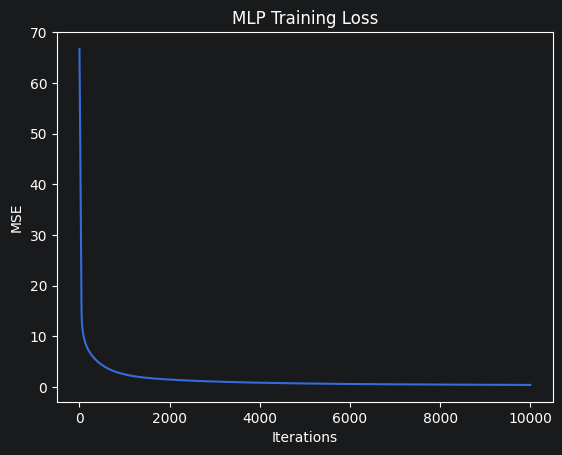

In [27]:
sns.lineplot(mlp.history_)
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.title("MLP Training Loss");

Loss converges.

In [28]:
y_pred_mlp = mlp.predict(X_test)

r2_score(y_test, y_pred_mlp), root_mean_squared_error(y_test, y_pred_mlp)

(0.8738102564259764, 2.7627876284887534)

This shows an improvement over the linear regression model.

## Discussion and Analysis

- Analyze the results of your metrics.
- Explain how does your analysis and machine learning help to solve your problem statement.
- Conclusion.

| **Model**             | **Test $R^2$** | **Test RMSE** |
|:----------------------|---------------:|--------------:|
| Linear Regression     |         0.7345 |        4.0072 |
| Multilayer Perceptron |         0.8738 |        2.7628 |

**Model performance.** The results show that both models are effective in predicting the PoU, with the MLP providing better predictive performance than linear regression. However, this improvement comes at the cost of interpretability. Unlike linear regression, the MLP makes it difficult to explain how individual indicators contribute to the final prediction. Therefore, although the MLP is preferable for prediction, linear regression remains valuable for interpreting how the selected indicators are associated with the PoU.

**Analysis.** The correlation analysis identified GDP, access to basic drinking water and sanitation services, food supply variability, and the prevalence of anemia as the indicators most strongly associated with undernourishment. These findings are consistent with the regression coefficients, reinforcing the relevance of the selected predictors. Together, the statistical analysis and machine learning models address the problem statement by identifying factors associated with food insecurity and demonstrating that they can be used to predict future levels of undernourishment.

**Conclusion.** Overall, the selected indicators provide meaningful information for modelling food security. The MLP offers better predictive performance, while linear regression provides greater interpretability, making the two models complementary for prediction and analysis.

## Bonus: Exporting Artifacts for the Streamlit App

The bonus Streamlit dashboard (`bonus/`) reuses the cleaned dataset and the models trained above instead of retraining them at runtime. The cells below persist the cleaned data, the area-code lookup table, and the trained model weights so the app can simply load them.

In [29]:
df_cleaned.to_csv("bonus/data/data.csv", index=False)
pd.read_csv("data/Food_Security_Data_E_AreaCodes.csv").to_csv("bonus/data/area_codes.csv", index=False)

In [30]:
import pickle

artifact = {
    "scaler_mean": ss.mean_,
    "scaler_std": ss.std_,
    "scaler_features": ss.features_,
    "lr_weights": lr.weights_,
    "mlp_weights": [layer.weights_ for layer in mlp.layers_ if layer.learnable_],
    "metrics": {
        "Linear Regression": {
            "r2": r2_score(y_test, y_pred),
            "rmse": root_mean_squared_error(y_test, y_pred),
        },
        "Multilayer Perceptron": {
            "r2": r2_score(y_test, y_pred_mlp),
            "rmse": root_mean_squared_error(y_test, y_pred_mlp),
        },
    },
}

with open("bonus/data/models.pkl", "wb") as f:
    pickle.dump(artifact, f)